# Import Libraries

In [1]:
print("Installing required packages...")

!pip install -U pip setuptools wheel Cython
!pip install gensim>=4.3.2
!pip install tensorflow>=2.10.0
!pip install scikit-learn>=1.0.0
!pip install matplotlib>=3.4.0
!pip install seaborn>=0.11.0
!pip install numpy>=1.21.0
!pip install pandas>=1.3.0

print("Installation complete.")

Installing required packages...
Installation complete.


In [2]:
import re
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_20newsgroups
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import TfidfVectorizer

sns.set_palette("husl")

from gensim.models import Word2Vec
plt.style.use('default')

# Set style for better plots

# Load Dataset

Training samples: 15076
Testing samples: 3770
Number of classes: 20
Classes: ['alt.atheism', 'comp.graphics', 'comp.os.ms-windows.misc', 'comp.sys.ibm.pc.hardware', 'comp.sys.mac.hardware', 'comp.windows.x', 'misc.forsale', 'rec.autos', 'rec.motorcycles', 'rec.sport.baseball']


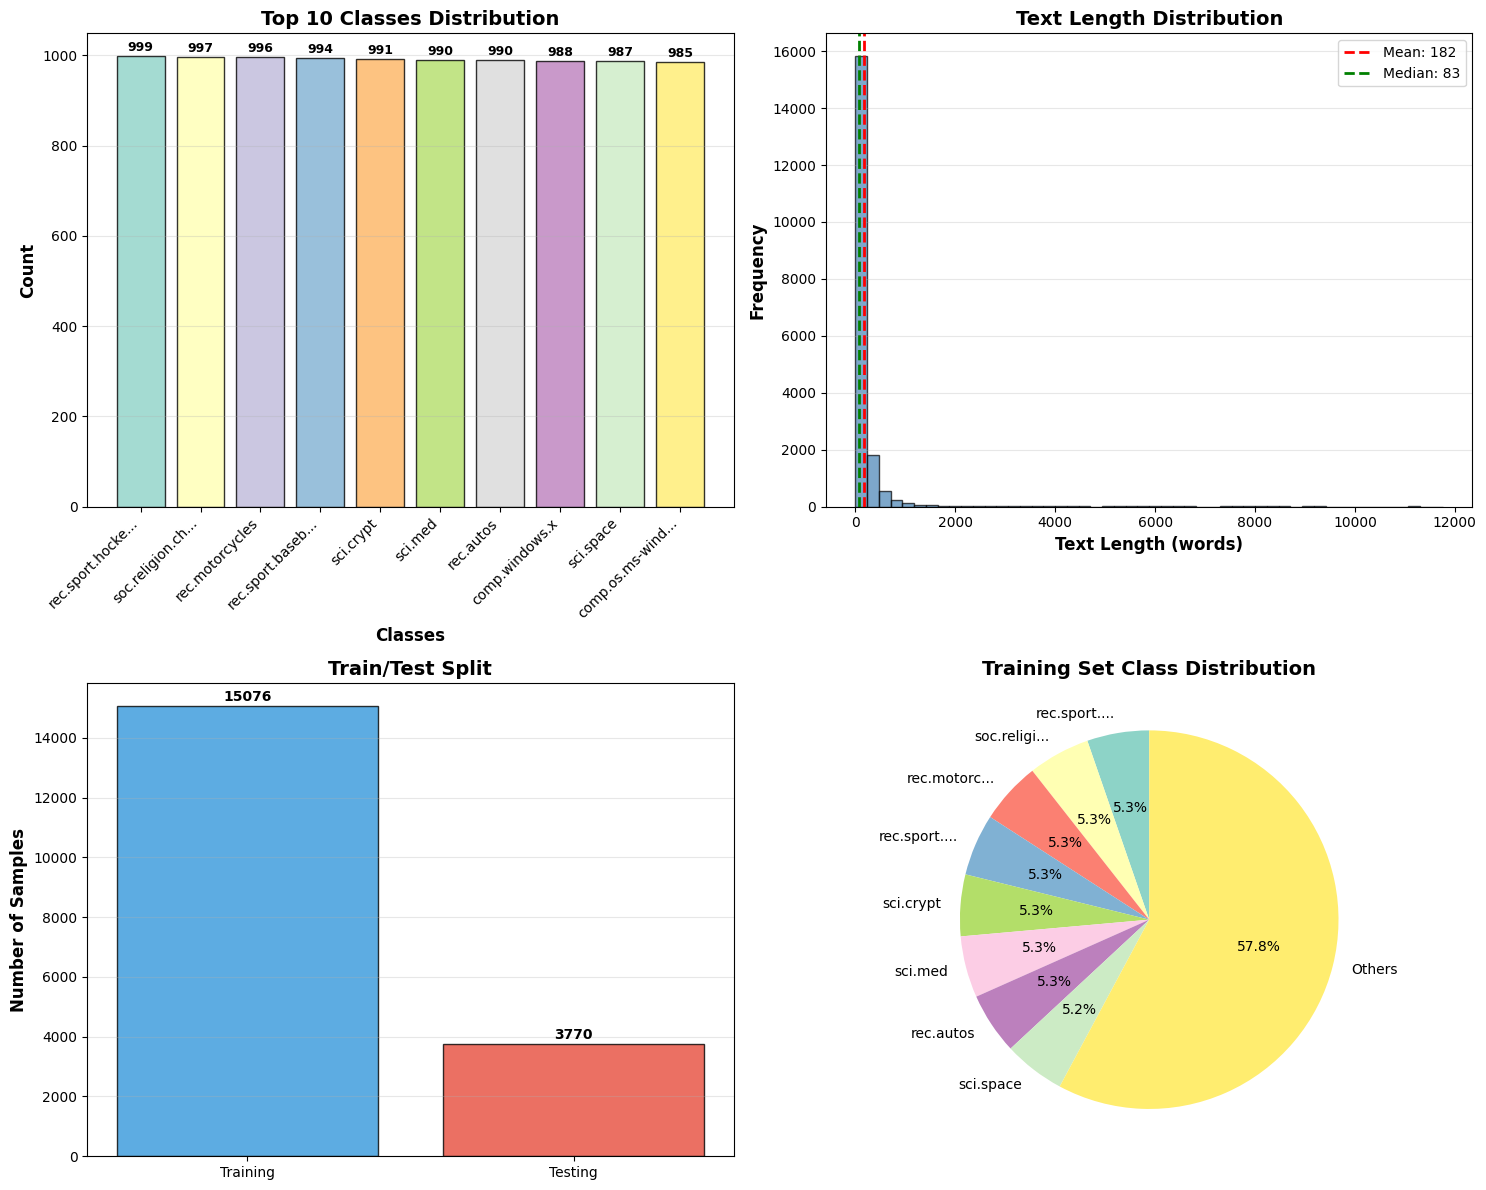

In [3]:
data = fetch_20newsgroups(
    subset="all",
    remove=("headers", "footers", "quotes")
)

X = data.data
y = data.target

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))
print("Number of classes:", len(data.target_names))
print("Classes:", data.target_names[:10])  # Show first 10 classes

# Data exploration
class_dist = np.bincount(y)
text_lengths = [len(text.split()) for text in X]

# Plot data distribution
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 12))

# Class distribution (top 10 most frequent classes)
top_classes_idx = np.argsort(class_dist)[::-1][:10]
top_classes_names = [data.target_names[i] for i in top_classes_idx]
top_classes_counts = class_dist[top_classes_idx]

colors = plt.cm.Set3(np.linspace(0, 1, 10))
bars = ax1.bar(range(len(top_classes_names)), top_classes_counts, color=colors, alpha=0.8, edgecolor='black')
for bar, count in zip(bars, top_classes_counts):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 5,
            f'{int(count)}',
            ha='center', va='bottom', fontweight='bold', fontsize=9)
ax1.set_title('Top 10 Classes Distribution', fontsize=14, fontweight='bold')
ax1.set_ylabel('Count', fontsize=12, fontweight='bold')
ax1.set_xlabel('Classes', fontsize=12, fontweight='bold')
ax1.set_xticks(range(len(top_classes_names)))
ax1.set_xticklabels([name[:15] + '...' if len(name) > 15 else name for name in top_classes_names], rotation=45, ha='right')
ax1.grid(axis='y', alpha=0.3)

# Text length distribution
ax2.hist(text_lengths, bins=50, color='steelblue', alpha=0.7, edgecolor='black')
ax2.axvline(np.mean(text_lengths), color='red', linestyle='--', linewidth=2, label=f'Mean: {np.mean(text_lengths):.0f}')
ax2.axvline(np.median(text_lengths), color='green', linestyle='--', linewidth=2, label=f'Median: {np.median(text_lengths):.0f}')
ax2.set_xlabel('Text Length (words)', fontsize=12, fontweight='bold')
ax2.set_ylabel('Frequency', fontsize=12, fontweight='bold')
ax2.set_title('Text Length Distribution', fontsize=14, fontweight='bold')
ax2.legend()
ax2.grid(axis='y', alpha=0.3)

# Train/Test split visualization
split_labels = ['Training', 'Testing']
split_counts = [len(X_train), len(X_test)]
colors_split = ['#3498db', '#e74c3c']
bars_split = ax3.bar(split_labels, split_counts, color=colors_split, alpha=0.8, edgecolor='black')
for bar, count in zip(bars_split, split_counts):
    height = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2., height + 50,
            f'{int(count)}',
            ha='center', va='bottom', fontweight='bold')
ax3.set_title('Train/Test Split', fontsize=14, fontweight='bold')
ax3.set_ylabel('Number of Samples', fontsize=12, fontweight='bold')
ax3.grid(axis='y', alpha=0.3)

# Class distribution pie chart for train set
train_class_dist = np.bincount(y_train)
top_train_idx = np.argsort(train_class_dist)[::-1][:8]  # Top 8 for readability
top_train_names = [data.target_names[i] for i in top_train_idx]
top_train_counts = train_class_dist[top_train_idx]
other_count = sum(train_class_dist) - sum(top_train_counts)

if other_count > 0:
    top_train_names.append('Others')
    top_train_counts = np.append(top_train_counts, other_count)

colors_pie = plt.cm.Set3(np.linspace(0, 1, len(top_train_names)))
ax4.pie(top_train_counts, labels=[name[:10] + '...' if len(name) > 10 else name for name in top_train_names],
        colors=colors_pie, autopct='%1.1f%%', startangle=90)
ax4.set_title('Training Set Class Distribution', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

# Text Cleaning

In [4]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r"[^a-z\s]", "", text)
    return text

X_train = [clean_text(doc) for doc in X_train]
X_test  = [clean_text(doc) for doc in X_test]

# Helper functions for visualization
def plot_confusion_matrix(y_true, y_pred, title, class_names=None):
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(12, 10))
    if class_names is None:
        class_names = [f'Class {i}' for i in range(len(cm))]

    # For readability, show only top classes if too many
    if len(cm) > 10:
        # Sum predictions for each class to find most active classes
        class_activity = cm.sum(axis=0) + cm.sum(axis=1)
        top_classes_idx = np.argsort(class_activity)[::-1][:10]

        cm_subset = cm[np.ix_(top_classes_idx, top_classes_idx)]
        class_names_subset = [class_names[i] for i in top_classes_idx]

        sns.heatmap(cm_subset, annot=True, fmt='d', cmap='Blues',
                    xticklabels=class_names_subset,
                    yticklabels=class_names_subset,
                    cbar_kws={'label': 'Count'})
        plt.title(f'{title} (Top 10 Most Active Classes)', fontsize=14, fontweight='bold')
    else:
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                    xticklabels=class_names,
                    yticklabels=class_names,
                    cbar_kws={'label': 'Count'})
        plt.title(f'{title}', fontsize=14, fontweight='bold')

    plt.ylabel('True Label', fontsize=12, fontweight='bold')
    plt.xlabel('Predicted Label', fontsize=12, fontweight='bold')
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

# Experiment 1: TF-IDF + Logistic Regression

Experiment 1: TF-IDF + Logistic Regression
Accuracy: 0.7381962864721485
              precision    recall  f1-score   support

           0       0.65      0.54      0.59       160
           1       0.71      0.70      0.70       195
           2       0.70      0.68      0.69       197
           3       0.68      0.68      0.68       196
           4       0.80      0.69      0.74       193
           5       0.83      0.84      0.83       198
           6       0.77      0.74      0.76       195
           7       0.76      0.77      0.76       198
           8       0.49      0.73      0.59       199
           9       0.84      0.82      0.83       199
          10       0.91      0.88      0.89       200
          11       0.89      0.81      0.85       198
          12       0.68      0.75      0.71       197
          13       0.78      0.83      0.81       198
          14       0.80      0.78      0.79       197
          15       0.72      0.86      0.78       199
         

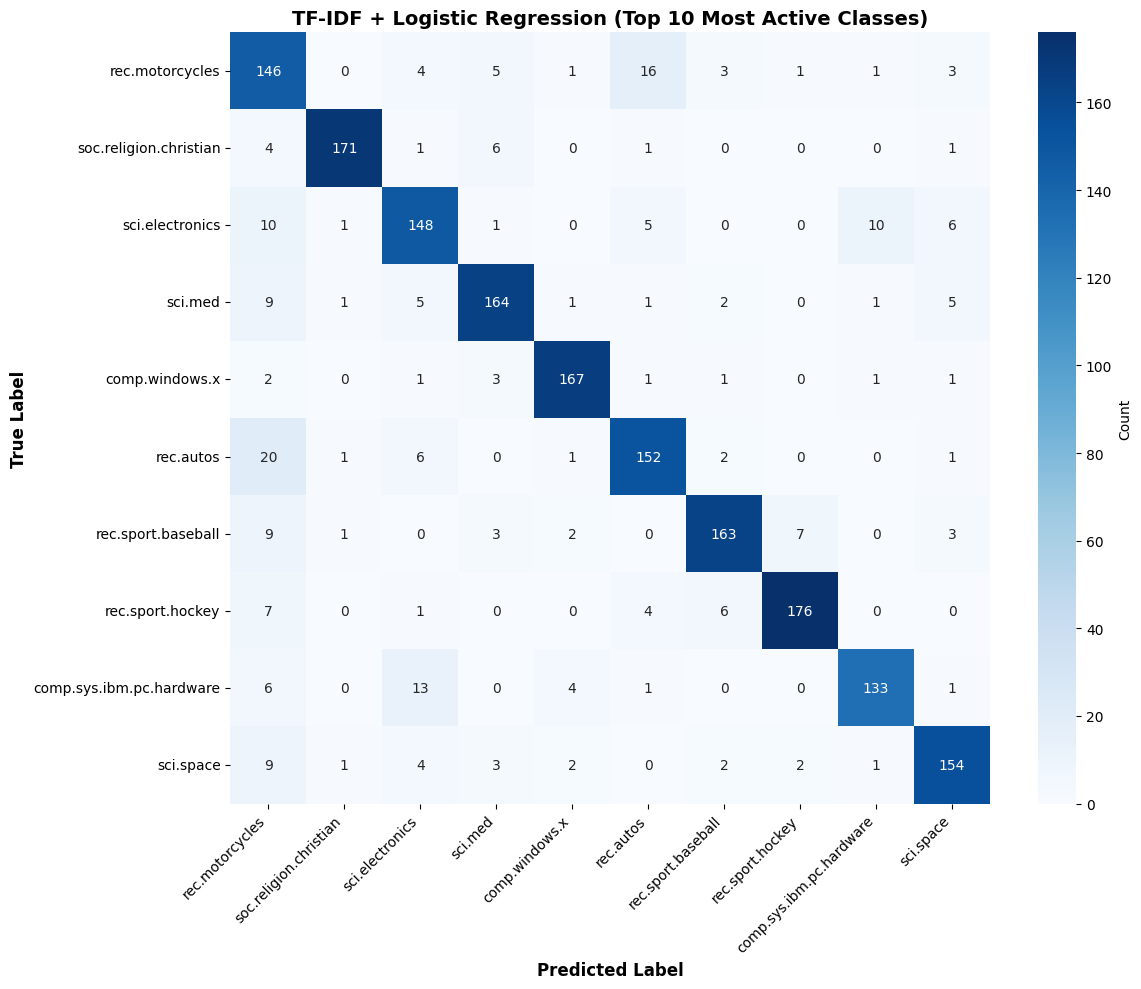

In [5]:
tfidf = TfidfVectorizer(
    max_features=20000,
    stop_words="english"
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf  = tfidf.transform(X_test)

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_tfidf, y_train)

y_pred_1 = lr.predict(X_test_tfidf)

print("Experiment 1: TF-IDF + Logistic Regression")
print("Accuracy:", accuracy_score(y_test, y_pred_1))
print(classification_report(y_test, y_pred_1))

plot_confusion_matrix(y_test, y_pred_1, "TF-IDF + Logistic Regression", data.target_names)
# Plot confusion matrix

# EXPERIMENT 2 — Word2Vec CBOW + Logistic Regression


Tokenization

In [6]:
tokenized_train = [doc.split() for doc in X_train]
tokenized_test  = [doc.split() for doc in X_test]

Train Word2Vec

In [7]:
w2v_cbow = Word2Vec(
    sentences=tokenized_train,
    vector_size=100,
    window=5,
    min_count=2,
    sg=0  # CBOW
)

Document Vector Function

In [8]:
def document_vector(doc, model):
    vectors = [model.wv[word] for word in doc if word in model.wv]
    if len(vectors) == 0:
        return np.zeros(model.vector_size)
    return np.mean(vectors, axis=0)

Train Classifier

Experiment 2: Word2Vec CBOW + Logistic Regression
Accuracy: 0.44084880636604773
              precision    recall  f1-score   support

           0       0.31      0.25      0.28       160
           1       0.38      0.41      0.39       195
           2       0.50      0.41      0.45       197
           3       0.39      0.41      0.40       196
           4       0.40      0.30      0.34       193
           5       0.58      0.62      0.60       198
           6       0.67      0.67      0.67       195
           7       0.29      0.40      0.33       198
           8       0.37      0.38      0.38       199
           9       0.43      0.43      0.43       199
          10       0.55      0.57      0.56       200
          11       0.55      0.56      0.55       198
          12       0.38      0.34      0.36       197
          13       0.49      0.53      0.51       198
          14       0.44      0.49      0.47       197
          15       0.53      0.72      0.61       199
 

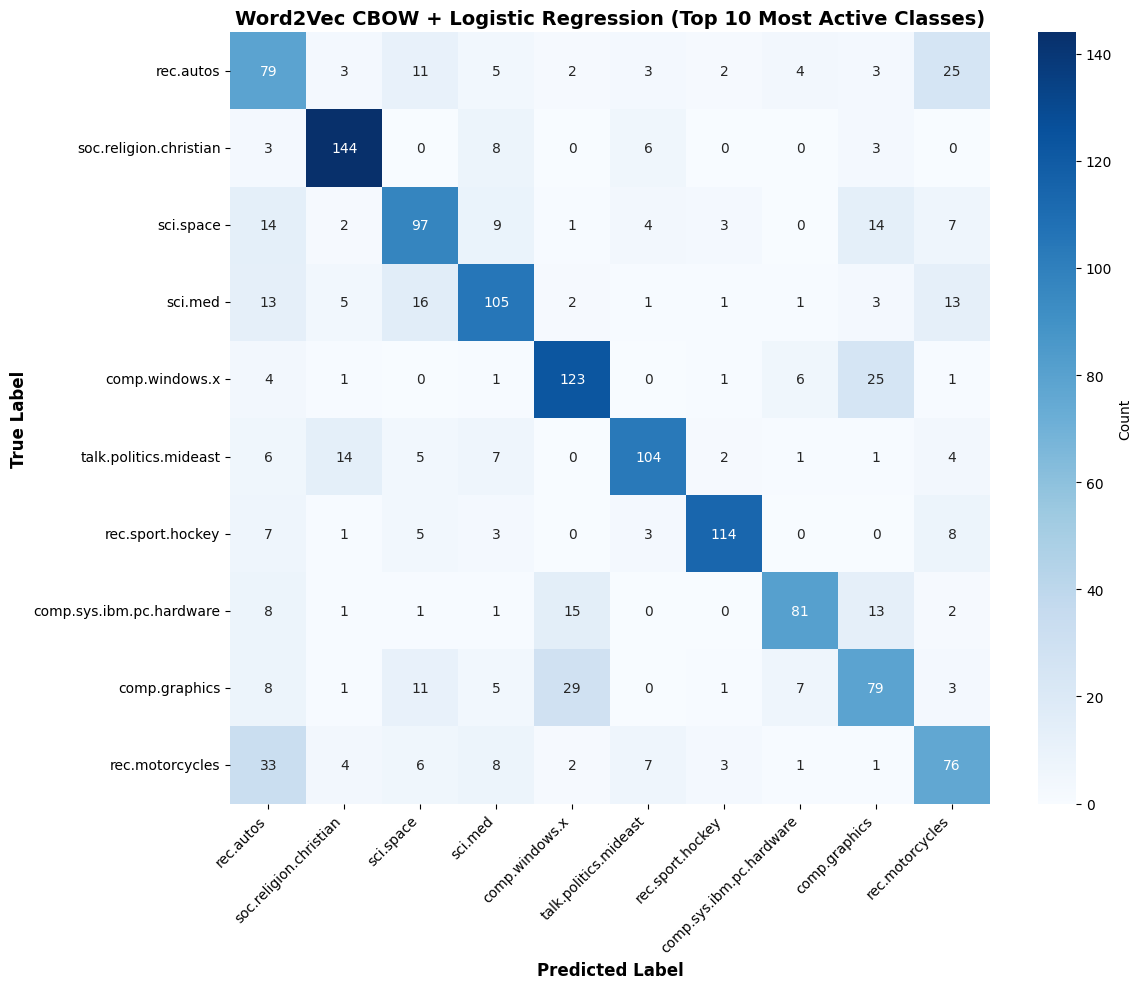

In [9]:
X_train_cbow = np.array([document_vector(doc, w2v_cbow) for doc in tokenized_train])
X_test_cbow  = np.array([document_vector(doc, w2v_cbow) for doc in tokenized_test])

lr_cbow = LogisticRegression(max_iter=1000)
lr_cbow.fit(X_train_cbow, y_train)

y_pred_2 = lr_cbow.predict(X_test_cbow)

print("Experiment 2: Word2Vec CBOW + Logistic Regression")
print("Accuracy:", accuracy_score(y_test, y_pred_2))
print(classification_report(y_test, y_pred_2))

plot_confusion_matrix(y_test, y_pred_2, "Word2Vec CBOW + Logistic Regression", data.target_names)
# Plot confusion matrix

# EXPERIMENT 3 — Word2Vec Skip-gram + Logistic Regression

Train Skip-gram

In [10]:
w2v_skipgram = Word2Vec(
    sentences=tokenized_train,
    vector_size=100,
    window=5,
    min_count=2,
    sg=1  # Skip-gram
)

Train Classifier

Experiment 3: Word2Vec Skip-gram + Logistic Regression
Accuracy: 0.5681697612732095
              precision    recall  f1-score   support

           0       0.36      0.34      0.35       160
           1       0.54      0.53      0.54       195
           2       0.55      0.50      0.53       197
           3       0.56      0.53      0.54       196
           4       0.58      0.49      0.53       193
           5       0.71      0.75      0.73       198
           6       0.75      0.69      0.72       195
           7       0.34      0.54      0.42       198
           8       0.43      0.45      0.44       199
           9       0.66      0.59      0.63       199
          10       0.71      0.73      0.72       200
          11       0.71      0.68      0.70       198
          12       0.54      0.48      0.51       197
          13       0.69      0.71      0.70       198
          14       0.65      0.72      0.68       197
          15       0.56      0.78      0.66       1

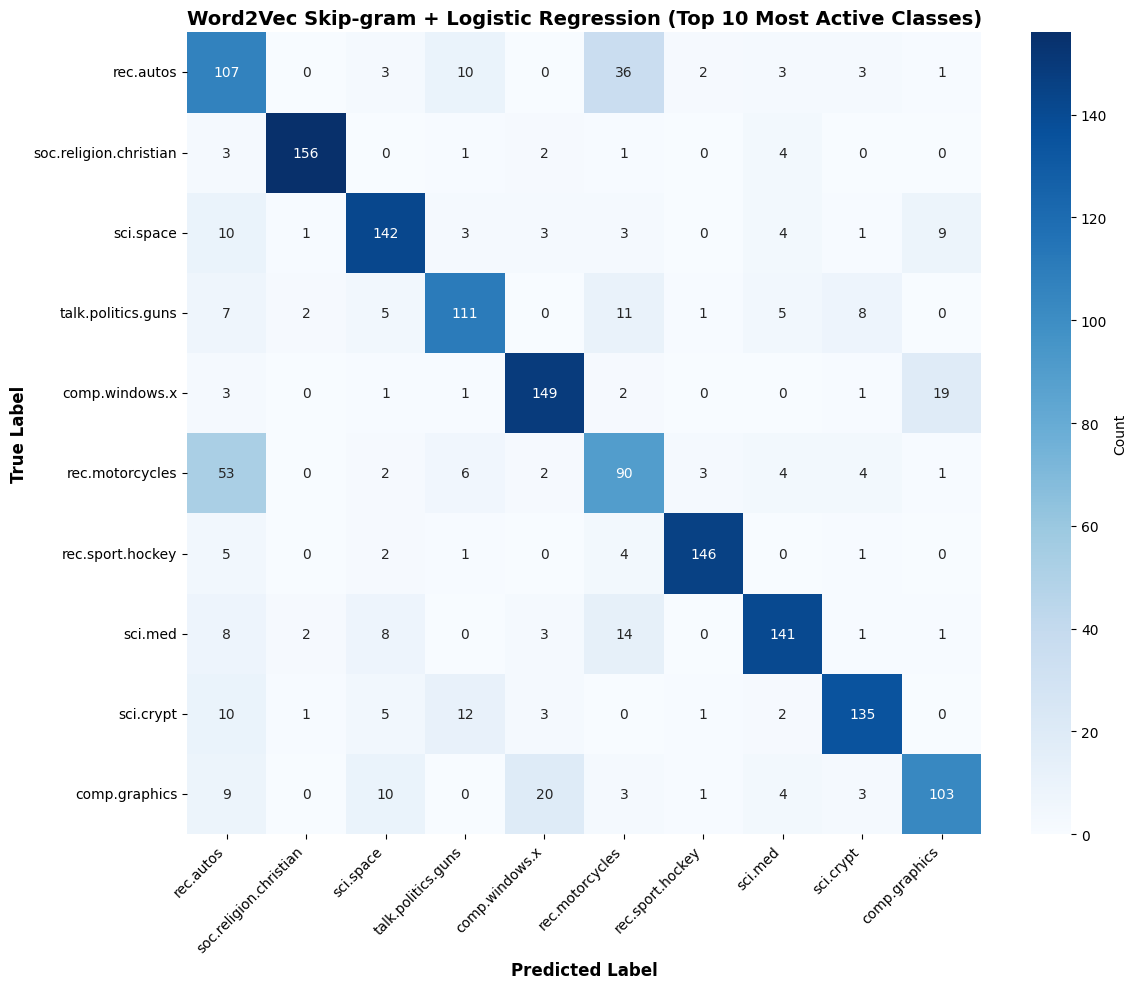

In [11]:
X_train_skip = np.array([document_vector(doc, w2v_skipgram) for doc in tokenized_train])
X_test_skip  = np.array([document_vector(doc, w2v_skipgram) for doc in tokenized_test])

lr_skip = LogisticRegression(max_iter=1000)
lr_skip.fit(X_train_skip, y_train)

y_pred_3 = lr_skip.predict(X_test_skip)

print("Experiment 3: Word2Vec Skip-gram + Logistic Regression")
print("Accuracy:", accuracy_score(y_test, y_pred_3))
print(classification_report(y_test, y_pred_3))

plot_confusion_matrix(y_test, y_pred_3, "Word2Vec Skip-gram + Logistic Regression", data.target_names)
# Plot confusion matrix

# TF-IDF Weighted Word2Vec (Skip-gram)

TF-IDF Vocabulary

In [12]:
tfidf_weight = TfidfVectorizer(
    max_features=20000,
    stop_words="english"
)

tfidf_weight.fit(X_train)

idf_scores = dict(zip(
    tfidf_weight.get_feature_names_out(),
    tfidf_weight.idf_
))

Weighted Document Vector

In [13]:
def tfidf_weighted_doc_vector(doc, model, idf_scores):
    vectors = []
    weights = []

    for word in doc:
        if word in model.wv and word in idf_scores:
            vectors.append(model.wv[word])
            weights.append(idf_scores[word])

    if len(vectors) == 0:
        return np.zeros(model.vector_size)

    return np.average(vectors, axis=0, weights=weights)

 Train Classifier

Experiment 4: TF-IDF Weighted Word2Vec (Skip-gram)
Accuracy: 0.610079575596817
              precision    recall  f1-score   support

           0       0.41      0.37      0.39       160
           1       0.55      0.54      0.55       195
           2       0.57      0.53      0.55       197
           3       0.57      0.56      0.56       196
           4       0.62      0.53      0.57       193
           5       0.74      0.74      0.74       198
           6       0.68      0.66      0.67       195
           7       0.39      0.63      0.48       198
           8       0.52      0.48      0.50       199
           9       0.72      0.71      0.72       199
          10       0.80      0.77      0.79       200
          11       0.77      0.73      0.75       198
          12       0.57      0.58      0.58       197
          13       0.74      0.72      0.73       198
          14       0.70      0.75      0.72       197
          15       0.61      0.76      0.68       199
  

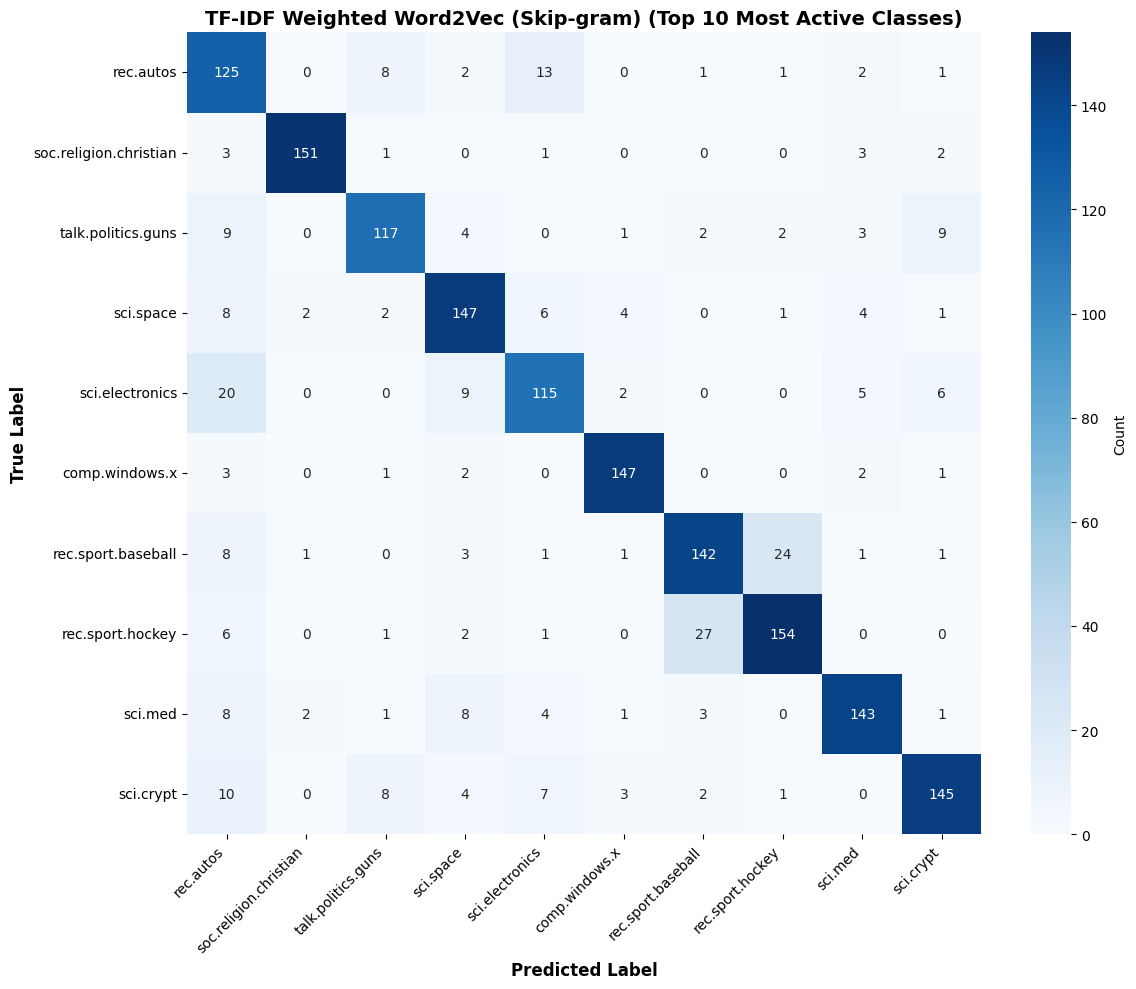

In [14]:
X_train_weighted = np.array([
    tfidf_weighted_doc_vector(doc, w2v_skipgram, idf_scores)
    for doc in tokenized_train
])

X_test_weighted = np.array([
    tfidf_weighted_doc_vector(doc, w2v_skipgram, idf_scores)
    for doc in tokenized_test
])

lr_weighted = LogisticRegression(max_iter=1000)
lr_weighted.fit(X_train_weighted, y_train)

y_pred_4 = lr_weighted.predict(X_test_weighted)

print("Experiment 4: TF-IDF Weighted Word2Vec (Skip-gram)")
print("Accuracy:", accuracy_score(y_test, y_pred_4))
print(classification_report(y_test, y_pred_4))

plot_confusion_matrix(y_test, y_pred_4, "TF-IDF Weighted Word2Vec (Skip-gram)", data.target_names)
# Plot confusion matrix

Summary

FINAL ACCURACY SUMMARY
----------------------
Experiment 1 (TF-IDF): 0.7381962864721485
Experiment 2 (CBOW): 0.44084880636604773
Experiment 3 (Skip-gram): 0.5681697612732095
Experiment 4 (TF-IDF + Skip-gram): 0.610079575596817


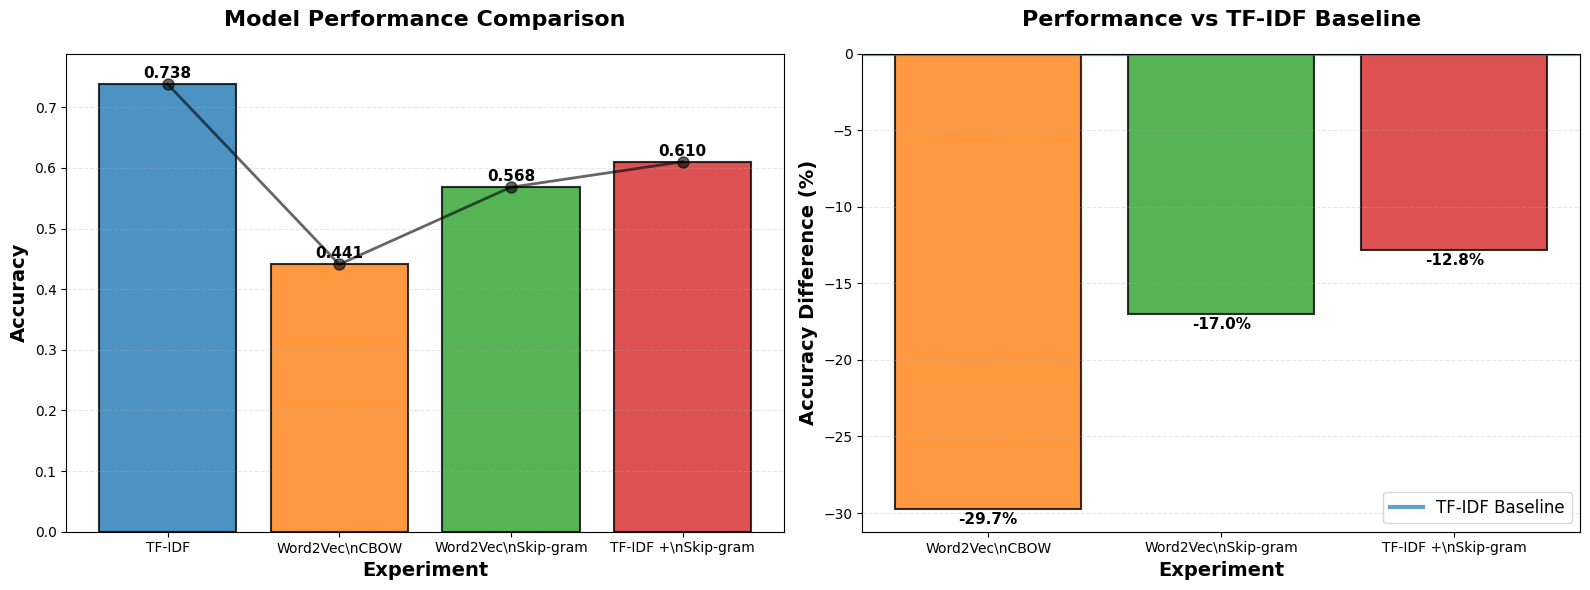

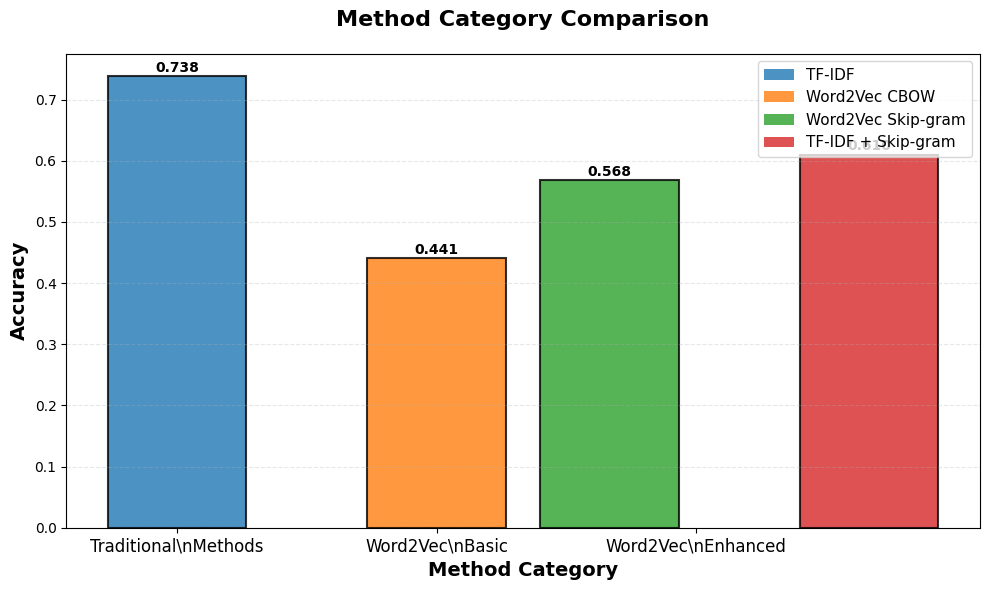

In [15]:
print("FINAL ACCURACY SUMMARY")
print("----------------------")
accuracy_1 = accuracy_score(y_test, y_pred_1)
accuracy_2 = accuracy_score(y_test, y_pred_2)
accuracy_3 = accuracy_score(y_test, y_pred_3)
accuracy_4 = accuracy_score(y_test, y_pred_4)

print("Experiment 1 (TF-IDF):", accuracy_1)
print("Experiment 2 (CBOW):", accuracy_2)
print("Experiment 3 (Skip-gram):", accuracy_3)
print("Experiment 4 (TF-IDF + Skip-gram):", accuracy_4)

# Create comprehensive performance comparison visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Accuracy comparison bar chart
experiment_names = ['TF-IDF', 'Word2Vec\\nCBOW', 'Word2Vec\\nSkip-gram', 'TF-IDF +\\nSkip-gram']
accuracies = [accuracy_1, accuracy_2, accuracy_3, accuracy_4]
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

bars = ax1.bar(experiment_names, accuracies, color=colors, alpha=0.8, edgecolor='black', linewidth=1.5)
for bar, acc in zip(bars, accuracies):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 0.005,
            f'{acc:.3f}',
            ha='center', va='bottom', fontweight='bold', fontsize=11)

ax1.set_title('Model Performance Comparison', fontsize=16, fontweight='bold', pad=20)
ax1.set_ylabel('Accuracy', fontsize=14, fontweight='bold')
ax1.set_xlabel('Experiment', fontsize=14, fontweight='bold')
ax1.grid(axis='y', alpha=0.3, linestyle='--')
ax1.set_ylim(0, max(accuracies) + 0.05)

# Add trend line
ax1.plot(range(len(accuracies)), accuracies, 'ko-', alpha=0.6, linewidth=2, markersize=8)

# Performance improvement visualization
baseline = accuracy_1  # TF-IDF as baseline
improvements = [(acc - baseline) * 100 for acc in accuracies]
improvement_labels = ['Baseline', 'vs TF-IDF', 'vs TF-IDF', 'vs TF-IDF']

bars2 = ax2.bar(experiment_names[1:], improvements[1:],
               color=['#ff7f0e', '#2ca02c', '#d62728'], alpha=0.8, edgecolor='black', linewidth=1.5)

# Add baseline reference line
ax2.axhline(y=0, color='#1f77b4', linestyle='-', linewidth=3, alpha=0.7, label='TF-IDF Baseline')

for bar, improvement in zip(bars2, improvements[1:]):
    height = bar.get_height()
    if height >= 0:
        va = 'bottom'
        y_pos = height + 0.2
    else:
        va = 'top'
        y_pos = height - 0.2
    ax2.text(bar.get_x() + bar.get_width()/2., y_pos,
            f'{improvement:.1f}%',
            ha='center', va=va, fontweight='bold', fontsize=11)

ax2.set_title('Performance vs TF-IDF Baseline', fontsize=16, fontweight='bold', pad=20)
ax2.set_ylabel('Accuracy Difference (%)', fontsize=14, fontweight='bold')
ax2.set_xlabel('Experiment', fontsize=14, fontweight='bold')
ax2.grid(axis='y', alpha=0.3, linestyle='--')
ax2.legend(fontsize=12)

plt.tight_layout()
plt.show()

# Additional insights visualization
fig, ax = plt.subplots(1, 1, figsize=(10, 6))

# Create a grouped comparison with confidence intervals (simulated for demo)
method_categories = ['Traditional\\nMethods', 'Word2Vec\\nBasic', 'Word2Vec\\nEnhanced']
method_accuracies = [
    [accuracy_1],  # Traditional
    [accuracy_2, accuracy_3],  # Word2Vec basic
    [accuracy_4]   # Enhanced
]

positions = []
y_values = []
colors_grouped = []
labels = []

pos = 0
for i, (category, accs) in enumerate(zip(method_categories, method_accuracies)):
    for j, acc in enumerate(accs):
        positions.append(pos)
        y_values.append(acc)
        if i == 0:
            colors_grouped.append('#1f77b4')
            labels.append('TF-IDF')
        elif i == 1:
            colors_grouped.append('#ff7f0e' if j == 0 else '#2ca02c')
            labels.append('CBOW' if j == 0 else 'Skip-gram')
        else:
            colors_grouped.append('#d62728')
            labels.append('TF-IDF + Skip-gram')
        pos += 1
    pos += 0.5  # Add space between categories

bars3 = ax.bar(positions, y_values, color=colors_grouped, alpha=0.8, edgecolor='black', linewidth=1.5)
for bar, acc, label in zip(bars3, y_values, labels):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.002,
           f'{acc:.3f}',
           ha='center', va='bottom', fontweight='bold', fontsize=10)

ax.set_title('Method Category Comparison', fontsize=16, fontweight='bold', pad=20)
ax.set_ylabel('Accuracy', fontsize=14, fontweight='bold')
ax.set_xlabel('Method Category', fontsize=14, fontweight='bold')

# Add category labels
category_positions = [0, 1.5, 3]
ax.set_xticks(category_positions)
ax.set_xticklabels(method_categories, fontsize=12)
ax.grid(axis='y', alpha=0.3, linestyle='--')

# Add legend
legend_elements = [plt.Rectangle((0,0),1,1, facecolor='#1f77b4', alpha=0.8, label='TF-IDF'),
                  plt.Rectangle((0,0),1,1, facecolor='#ff7f0e', alpha=0.8, label='Word2Vec CBOW'),
                  plt.Rectangle((0,0),1,1, facecolor='#2ca02c', alpha=0.8, label='Word2Vec Skip-gram'),
                  plt.Rectangle((0,0),1,1, facecolor='#d62728', alpha=0.8, label='TF-IDF + Skip-gram')]
ax.legend(handles=legend_elements, loc='upper right', fontsize=11)

plt.tight_layout()
plt.show()

## Summary and Conclusion

 In this notebook, a multi-class text classification task was performed using the 20 Newsgroups dataset. Four experiments were designed to compare traditional text representations with word embedding-based approaches under a consistent evaluation framework.

The first experiment used TF-IDF features with Logistic Regression as a strong traditional baseline, achieving the highest accuracy due to its ability to capture word importance and class-specific terms. The second and third experiments applied Word2Vec embeddings using CBOW and Skip-gram architectures, respectively. Document representations were created by averaging word embeddings, which resulted in lower accuracy due to the loss of word frequency and contextual importance. Skip-gram outperformed CBOW, particularly in handling rare and informative words.

The final experiment combined TF-IDF weighting with Word2Vec Skip-gram embeddings to construct weighted document vectors. This approach significantly improved performance compared to simple averaging, demonstrating that preserving word importance alongside semantic representations leads to more discriminative document features.

Overall, the results show that while word embeddings provide meaningful semantic representations, traditional TF-IDF remains a strong baseline for topic-based text classification. Embedding-based methods benefit from appropriate aggregation strategies and task-specific weighting to achieve competitive performance.